# Prática de Auditoria: Regressão Descontínua (RDD)

Este notebook é um guia prático para aplicação da técnica de **Regressão Descontínua (RDD)** em contextos de auditoria e avaliação de impacto. O RDD é utilizado quando o acesso a um tratamento ou programa é definido por um ponto de corte (*cutoff*) em uma variável contínua (variável de controle ou *running variable*).

## 1. Configuração do Ambiente
Primeiro, vamos clonar a biblioteca `pyrdd`, que contém as funções utilitárias para simulação e cálculo dos modelos de regressão local.

In [1]:
!git clone https://gitlab.com/aloisio/pyrdd.git

Cloning into 'pyrdd'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 22 (delta 9), reused 17 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 8.16 KiB | 8.16 MiB/s, done.
Resolving deltas: 100% (9/9), done.


## 2. Preparação dos Dados
Nesta etapa, montamos o Google Drive para acessar bases de dados externas (como o estudo de caso de mortalidade).

In [2]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/Aulas/Aulas IDP/2026/Auditoria de Dados e Accountability/modulo III - Aud operacional/rdd'

Mounted at /content/drive


## Imports

In [3]:
import pyrdd.utils as rdd
import matplotlib.pyplot as plt
import pandas as pd
import os

## 3. Sharp RDD (RDD Nítido)

No **Sharp RDD**, a atribuição do tratamento é perfeitamente determinada pelo ponto de corte.
- Se $X \geq c$, o indivíduo **sempre** recebe o tratamento.
- Se $X < c$, o indivíduo **nunca** recebe o tratamento.

### Dados Simulados
Vamos validar o método criando um cenário onde conhecemos o impacto real (0.5) no ponto de corte (1.0).

In [4]:
cutoff = 1
data = rdd.sim_data(10000, cut=cutoff, impact =.5)
data = data.sort_values(by="x")
data.head()

,y,x,c1,c2,w
9550,-4.504033,-2.656440,3.038637,4.137347,0
7408,-3.912078,-2.294858,1.177786,3.835546,0
5920,-3.914137,-2.260615,0.814280,1.630711,0
4416,-3.441691,-2.253034,1.632489,-5.530570,0
8009,-3.716320,-2.219132,1.692289,-0.089407,0


# Visualizando os dados graficamente

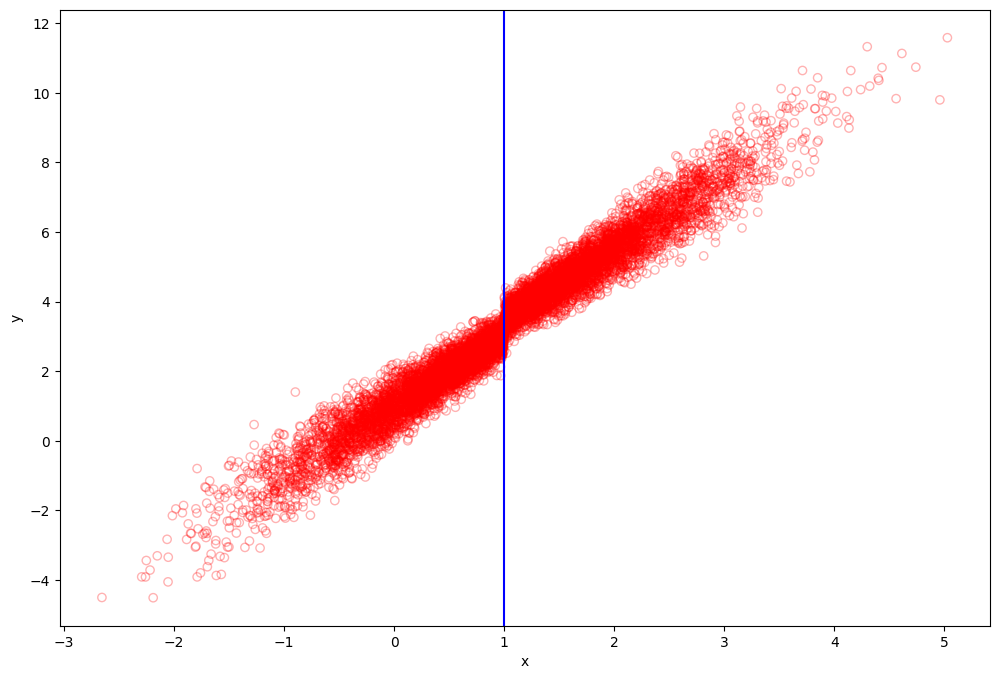

In [5]:
plt.figure(figsize=(12, 8))
plt.scatter(data['x'], data['y'], facecolors='none', edgecolors='r', alpha=.3)
plt.xlabel('x')
plt.ylabel('y')
plt.axvline(x=cutoff, color='b')
plt.show()
plt.close()

### Análise Visual da Descontinuidade

No gráfico acima, observamos a relação entre a variável de controle ($x$) e o resultado ($y$):

*   **Pontos Vermelhos**: Representam cada observação individual (unidade auditada).
*   **Linha Azul**: Indica o ponto de corte (*cutoff*) em $x=1.0$.

**O que procurar como auditor?**
Note que há um deslocamento visível no nível de $y$ exatamente quando cruzamos a linha azul. Esse 'salto' é a primeira evidência visual de que o tratamento (atribuído após o ponto 1.0) está gerando um impacto real. Se não houvesse efeito, os pontos seguiriam uma tendência contínua, sem degraus.

### Agrupamento de Dados (*Binning*)
Para reduzir o ruído visual em grandes datasets, utilizamos `rdd.bin_data`. Isso agrupa as observações em 'baldes' (bins) e facilita a visualização da descontinuidade no ponto de corte.

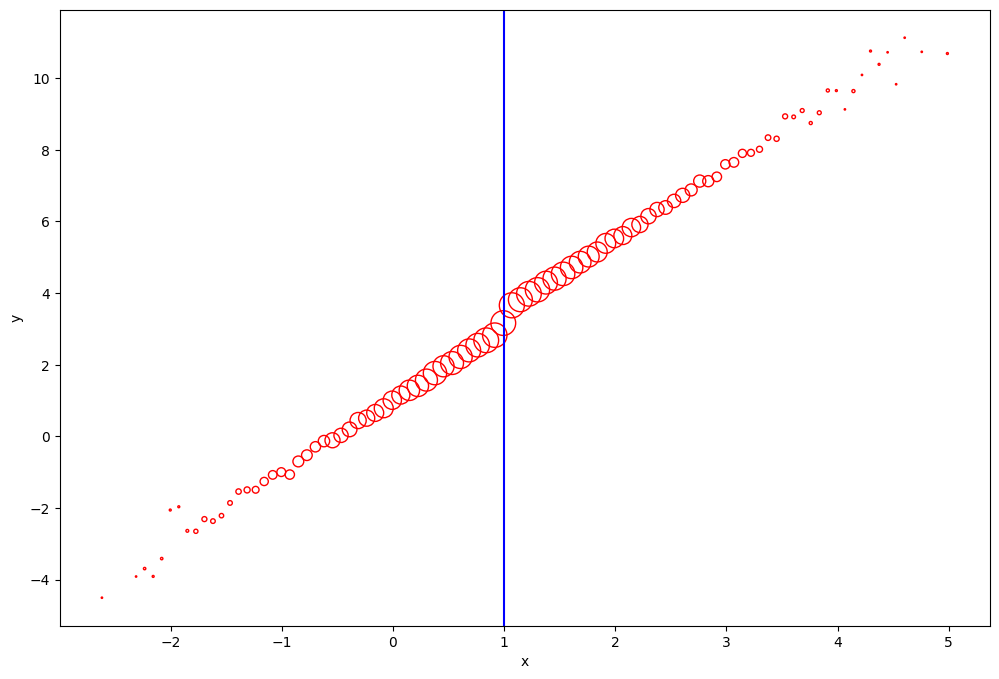

In [ ]:
binned = rdd.bin_data(data, 'y', 'x', 100)

plt.figure(figsize=(12, 8))
plt.scatter(binned['x'], binned['y'],
    s = binned['n_obs'], facecolors='none', edgecolors='r')
plt.axvline(x=cutoff, color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.close()

### Análise de Dados Agrupados (*Binned Scatter Plot*)

Ao comparar este gráfico com o anterior, notamos uma diferença fundamental na clareza dos dados:

1.  **Redução de Ruído**: Enquanto o gráfico anterior exibia 10.000 pontos sobrepostos, dificultando a percepção da média, o processo de *binning* agrupa esses pontos em 100 'baldes'.
2.  **Peso das Observações**: O tamanho de cada círculo vermelho agora representa a quantidade de dados naquele intervalo ($n\_obs$).
3.  **Nitidez do Salto**: A descontinuidade no ponto azul ($x=1.0$) torna-se muito mais evidente. Para um auditor, este gráfico é uma prova mais robusta da existência de um efeito de tratamento, pois mostra que a **média** dos resultados muda drasticamente ao cruzar a fronteira regulatória.

Esta técnica é preferível em relatórios de auditoria para demonstrar visualmente que o impacto não é fruto de casos isolados (*outliers*), mas sim uma mudança estrutural no comportamento dos dados.

### Teste de Atribuição (Variável W)
No Sharp RDD, a variável de tratamento $W$ deve saltar bruscamente de 0 para 1 exatamente no ponto de corte.

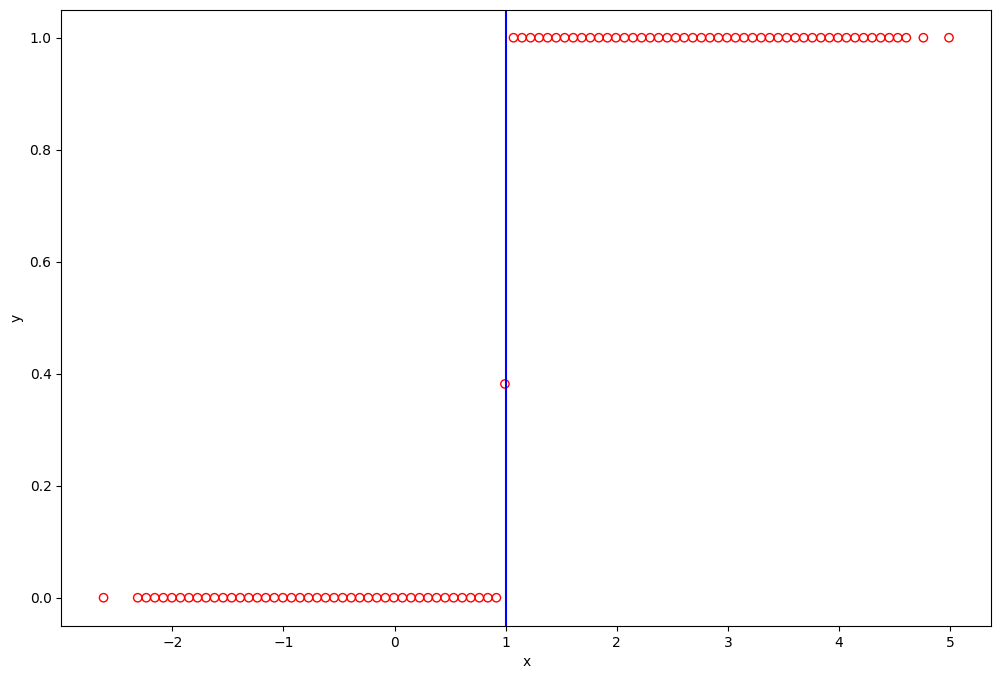

In [ ]:
dens = rdd.density_test(data, 'x', 'w', n_bins = 100)

plt.figure(figsize=(12, 8))
plt.scatter(dens.mid_point, dens.w_density, facecolors='none', edgecolors='r')
plt.axvline(x=cutoff, color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.close()

### Verificação da Regra de Atribuição (Tratamento $W$)

Este gráfico é um teste de diagnóstico crucial para confirmar se estamos lidando com um **Sharp RDD**:

*   **Eixo Y ($w\_density$)**: Representa a proporção de indivíduos tratados.
*   **Comportamento**: Note que à esquerda da linha azul ($x < 1.0$), a probabilidade de tratamento é **zero**. À direita ($x \geq 1.0$), ela salta imediatamente para **um** (100%).

**Conclusão para Auditoria**:
Este padrão confirma que a regra de elegibilidade foi seguida à risca. Não há 'contaminação' (indivíduos tratados antes da hora ou não tratados após o corte). Se houvesse pontos intermediários entre 0 e 1, o auditor deveria migrar a análise para um modelo **Fuzzy RDD**.

## 4. Otimização do Modelo

### Calculando o *Bandwidth* (Largura de Banda) Ideal
O *bandwidth* define a janela de dados ao redor do cutoff que será considerada.
- **Janela muito grande**: Introduz viés (inclui dados longe do corte).
- **Janela muito pequena**: Aumenta a variância (poucos dados).

Usamos o algoritmo de Imbens-Kalyanaraman (`ik_sharp_bandwidth`) para encontrar o equilíbrio ótimo.

In [6]:
hopt = rdd.ik_sharp_bandwidth(data, "x", "y", cut=1)
hopt

np.float64(1.4451859473240158)

## Restringindo os dados (passo não obrigatório)

In [7]:
data_bw = rdd.truncated_data(data, "x", bandwidth=hopt, yname="y", cut=1)
data_bw.head()

,y,x,c1,c2,w
70,-0.076115,-0.444114,0.191398,5.119109,0
7368,-0.685300,-0.443811,-0.908767,3.903652,0
5217,0.484592,-0.443121,-0.293305,-3.932107,0
7871,-0.868497,-0.442557,0.740410,-8.223039,0
5827,0.423146,-0.442013,-0.029731,1.103209,0


## Visualizando

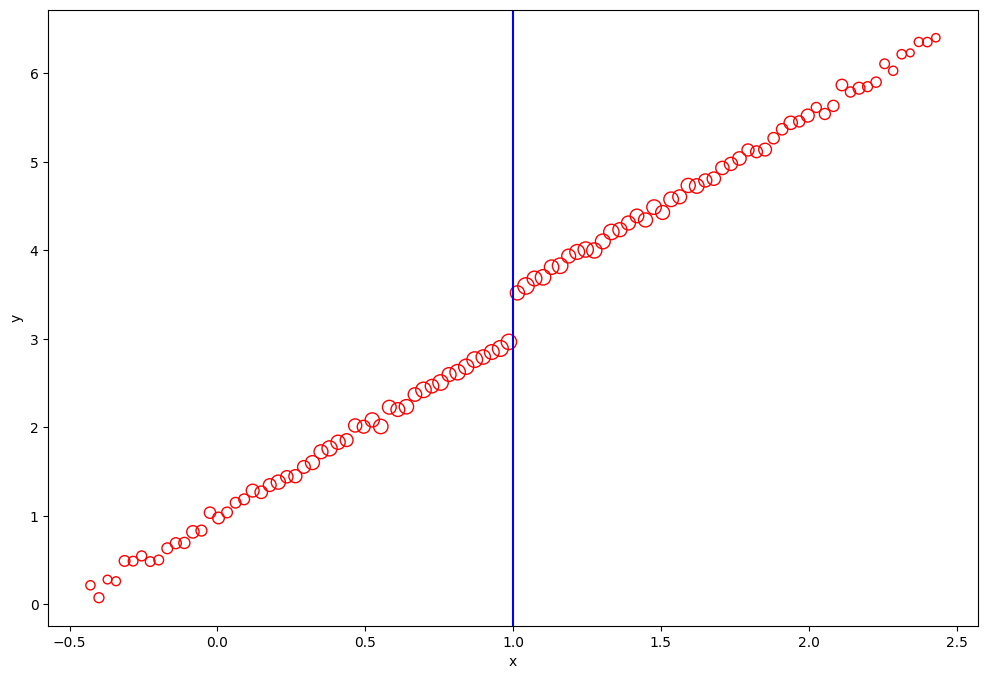

In [8]:
binned = rdd.bin_data(data_bw, 'y', 'x', 100)

plt.figure(figsize=(12, 8))
plt.scatter(binned['x'], binned['y'],
    s = binned['n_obs'], facecolors='none', edgecolors='r')
plt.axvline(x=cutoff, color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.close()

## 5. Estimativa do Impacto

Ao executar `rdd.sharp_rdd`, estamos realizando uma regressão linear local.

**Como interpretar os resultados:**
- **Intercept**: O valor esperado da variável dependente logo à esquerda do ponto de corte.
- **threshold (Impacto)**: O tamanho do 'salto' no ponto de corte. É o efeito do tratamento.
- **P>|t| (p-valor)**: Se for menor que 0.05, o impacto é estatisticamente significante.
- **Kernel**: Define o peso dos dados. O kernel `triang` (triangular) dá mais peso às observações mais próximas do ponto de corte.

### 5.1 Estimativa Sem Restrições (Baseline)
Primeiro, calculamos o modelo usando todos os dados disponíveis e uma regressão linear simples em cada lado do ponto de corte.

In [9]:
model = rdd.sharp_rdd(data, "x", "y", cut=cutoff, bw=None, kernel=None)
model.summary().tables[1]

y~x*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.9980,0.010,297.606,0.000,2.978,3.018
x,1.9973,0.010,196.739,0.000,1.977,2.017
threshold,0.5081,0.014,35.908,0.000,0.480,0.536
x:threshold,0.0114,0.014,0.807,0.420,-0.016,0.039


In [10]:
model.params["threshold"]

np.float64(0.5080589129861397)

### 5.2 Estimativa com Bandwidth Otimizado (IK)
Agora, limitamos a amostra à janela ideal calculada pelo algoritmo de Imbens-Kalyanaraman. Isso reduz o viés causado por dados muito distantes do ponto de corte.

In [11]:
model = rdd.sharp_rdd(data, "x", "y", cut=cutoff, bw=hopt, kernel=None)
model.summary().tables[1]

y~x*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.0049,0.011,276.968,0.000,2.984,3.026
x,2.0109,0.015,133.794,0.000,1.981,2.040
threshold,0.5014,0.015,32.665,0.000,0.471,0.531
x:threshold,-0.0019,0.021,-0.088,0.930,-0.044,0.040


### 5.3 Estimativa com Bandwidth e Kernel Triangular
Por fim, aplicamos o **Kernel Triangular**. Diferente do kernel uniforme (padrão), o triangular atribui pesos maiores às observações que estão 'coladas' no ponto de corte, o que geralmente oferece a estimativa mais robusta para auditoria.

In [12]:
model_triang = rdd.sharp_rdd(data, "x", "y", cut=cutoff, bw=hopt, kernel="triang")
display(model_triang.summary().tables[1])
print(f"Impacto (Threshold) com Kernel Triangular: {model_triang.params['threshold']:.4f}")

y~x*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.0058,0.009,330.139,0.000,2.988,3.024
x,2.0131,0.017,115.421,0.000,1.979,2.047
threshold,0.5090,0.013,39.522,0.000,0.484,0.534
x:threshold,-0.0247,0.025,-0.998,0.318,-0.073,0.024


Impacto (Threshold) com Kernel Triangular: 0.5090


### Comparação dos Resultados

Ao observar as três tabelas acima, note como o coeficiente `threshold` se comporta:
- **Sem BW**: Utiliza muita informação, mas pode ser enviesado por tendências globais dos dados.
- **Com BW**: Foca na vizinhança do corte, tornando a comparação 'antes vs depois' mais justa.
- **Com Kernel Triangular**: É tecnicamente o mais rigoroso. Se o valor do impacto (0.5 no nosso caso simulado) permanecer estável e estatisticamente significante ($P>|t| < 0.05$) em todas as configurações, temos uma evidência de auditoria extremamente forte.

### Visualizando a regressão local

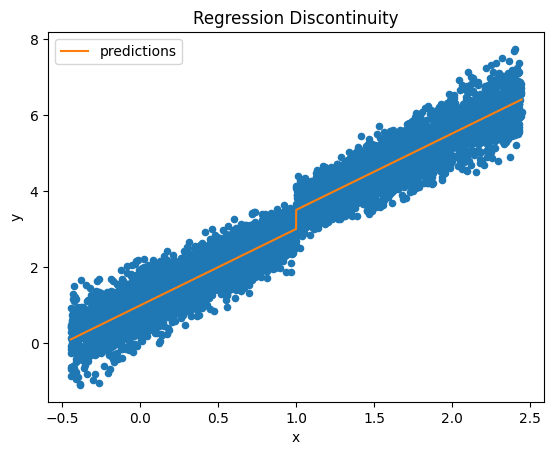

In [ ]:
trunc = rdd.truncated_data(data, "x", bandwidth=hopt, yname="y", cut=1)
ax = trunc.plot.scatter(x="x", y="y", color="C0")
trunc.assign(predictions=model.fittedvalues).plot(x="x", y="predictions", ax=ax, color="C1")
plt.title("Regression Discontinuity");


## Exercício:
### RDD Sharp com poucos dados
* Gere um novo dataset simulado (small_data) com apenas 200 observações, mantendo os demais parâmetros
* Calcule o novo BW ótimo (small_hopt)
* Execute o sharp RDD 3 vezes com os seguintes parâmetros:
    * bw=None, kernel=None
    * bw=small_hopt Kernel=None
    * bw=small_hopt Kernel="triang"
* Compare os resultados com os obtidos com o dataset maior.
* Com o dataset menor, o uso do bw e do kernel surtiu mais efeito?    

In [13]:
small_data = rdd.sim_data(200, cut=cutoff, impact =.5)

In [14]:
small_hopt = rdd.ik_sharp_bandwidth(small_data, "x", "y", cut=1)
small_hopt

np.float64(1.2735046046805056)

In [15]:
model = rdd.sharp_rdd(small_data, "x", "y", cut=cutoff, bw=None, kernel=None)
model.summary().tables[1]

y~x*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.0943,0.075,41.304,0.000,2.947,3.242
x,2.1004,0.084,25.129,0.000,1.936,2.265
threshold,0.3822,0.101,3.771,0.000,0.182,0.582
x:threshold,-0.1548,0.111,-1.393,0.165,-0.374,0.064


In [16]:
model = rdd.sharp_rdd(small_data, "x", "y", cut=cutoff, bw=small_hopt, kernel=None)
model.summary().tables[1]

y~x*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.0871,0.087,35.517,0.000,2.916,3.259
x,2.1031,0.136,15.498,0.000,1.835,2.371
threshold,0.4030,0.119,3.391,0.001,0.168,0.638
x:threshold,-0.1779,0.183,-0.971,0.333,-0.540,0.184


In [17]:
model = rdd.sharp_rdd(small_data, "x", "y", cut=cutoff, bw=small_hopt, kernel="triang")
model.summary().tables[1]

y~x*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.0616,0.072,42.695,0.000,2.920,3.203
x,2.0323,0.160,12.705,0.000,1.717,2.348
threshold,0.3979,0.098,4.076,0.000,0.205,0.591
x:threshold,-0.0275,0.212,-0.129,0.897,-0.447,0.392


## Usando covariáveis na regressão local
Estudos indicam que, em determinadas situações, o acréscimo de covaráveis pode aumentar a precisão das estimativas. Lembrando que precisão é diferente de exatidão.

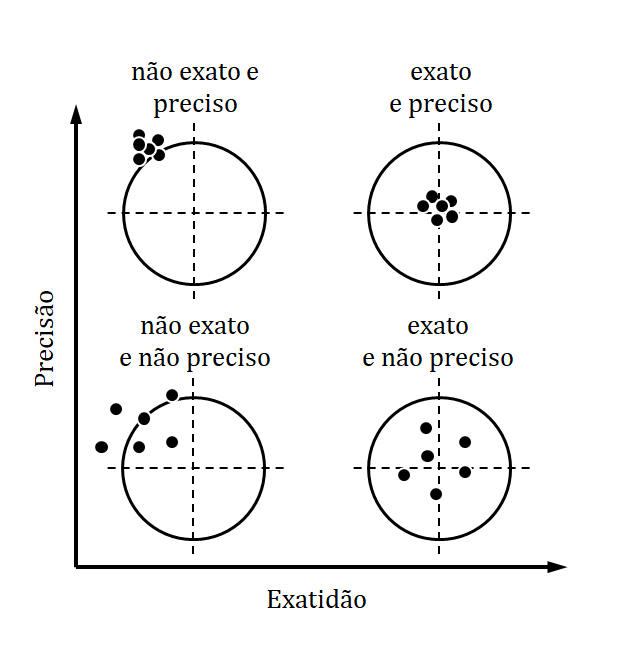

### Modelo com covariáveis:

In [18]:
model = rdd.sharp_rdd(small_data, "x", "y", cut=1, bw=small_hopt, kernel="triang", covars=["c1","c2"])
model.summary().tables[1]

y~x*threshold + c1 + c2


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.0383,0.055,54.796,0.000,2.929,3.148
x,1.9954,0.123,16.185,0.000,1.752,2.239
threshold,0.4554,0.076,6.022,0.000,0.306,0.605
x:threshold,-0.0086,0.163,-0.053,0.958,-0.331,0.314
c1,0.2481,0.023,10.796,0.000,0.203,0.293
c2,0.0019,0.006,0.316,0.753,-0.010,0.014


## Pergunta:
No exemplo acima, alguma covariável é não significante?

Repita o comando, retirando a variável não significativa e observe o efeito na precisão.


In [19]:
model = rdd.sharp_rdd(small_data, "x", "y", cut=1, bw=small_hopt, kernel="triang", covars=["c1"])
model.summary().tables[1]

y~x*threshold + c1


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.0401,0.055,55.255,0.000,2.931,3.149
x,1.9980,0.123,16.285,0.000,1.756,2.240
threshold,0.4529,0.075,6.038,0.000,0.305,0.601
x:threshold,-0.0086,0.163,-0.053,0.958,-0.330,0.313
c1,0.2486,0.023,10.865,0.000,0.203,0.294


# 6. Fuzzy RDD (RDD Difuso)

No **Fuzzy RDD**, o ponto de corte não garante o tratamento, mas altera a **probabilidade** de recebê-lo. É comum em auditorias onde há descumprimento de regras (*non-compliance*).

- Exemplo: Alunos com nota > 7 *deveriam* receber bolsa, mas alguns não recebem por falta de documentos, ou alguns com nota < 7 recebem por via judicial.

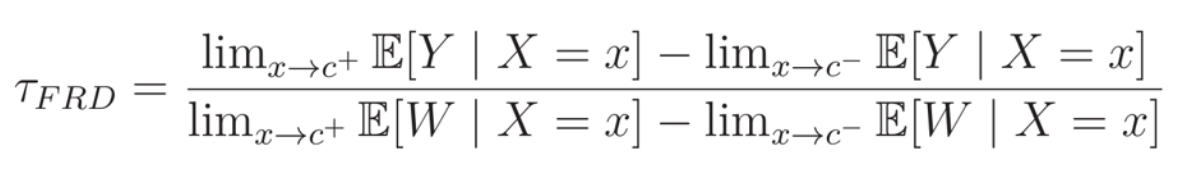

## Dados Fuzzy Simulados

In [20]:
cutoff = 1
data = rdd.sim_data(100000, cut=cutoff, impact =.5, fuzy=True)
data = data.sort_values(by="x")
data.head()

,y,x,c1,c2,w
72386,-7.467423,-3.326887,-1.418804,-10.439397,0
26206,-6.981218,-3.233165,1.087548,4.680269,0
41103,-6.163233,-3.088489,1.314640,-10.356065,0
48752,-5.926818,-3.041680,-0.360922,1.419686,0
42698,-5.532484,-2.943142,1.768257,-1.670740,0


### Vamos "ver" os dados

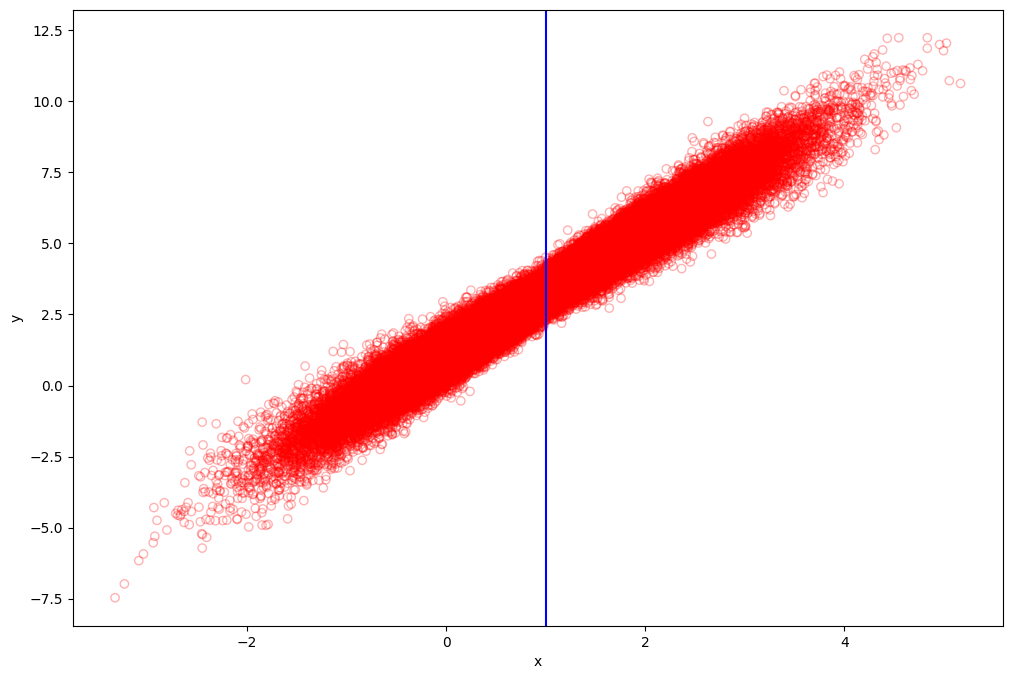

In [21]:
plt.figure(figsize=(12, 8))
plt.scatter(data['x'], data['y'], facecolors='none', edgecolors='r', alpha=.3)
plt.xlabel('x')
plt.ylabel('y')
plt.axvline(x=cutoff, color='b')
plt.show()
plt.close()

### Agora com dados *binned*

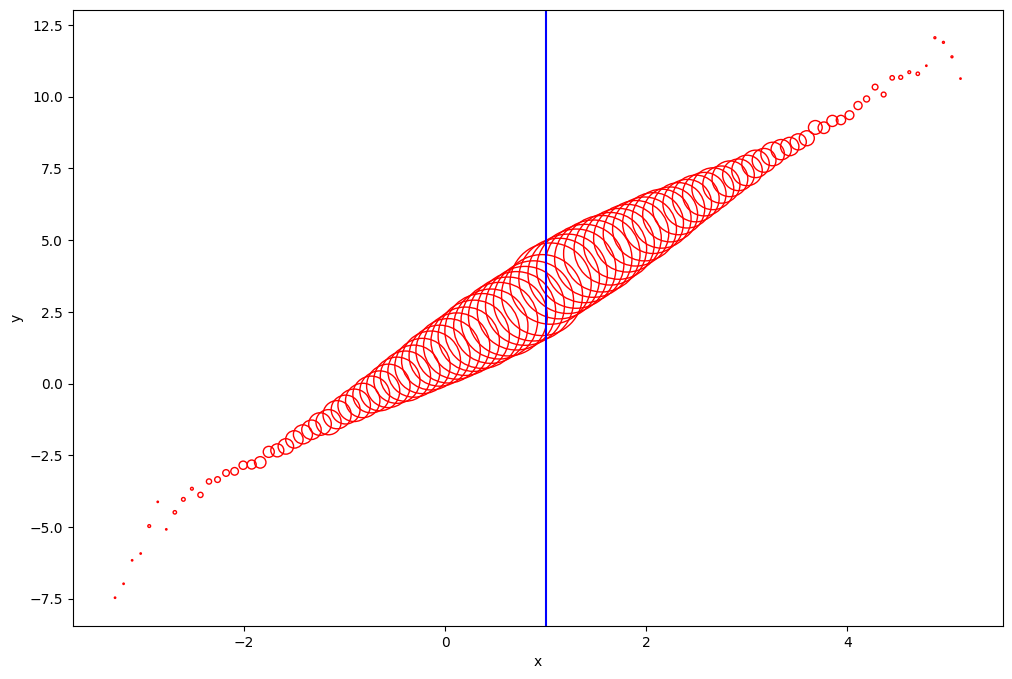

In [22]:
binned = rdd.bin_data(data, 'y', 'x', 100)

plt.figure(figsize=(12, 8))
plt.scatter(binned['x'], binned['y'],
    s = binned['n_obs'], facecolors='none', edgecolors='r')
plt.axvline(x=cutoff, color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.close()

### Vamos verificar a probabilidade do tratamento (W)

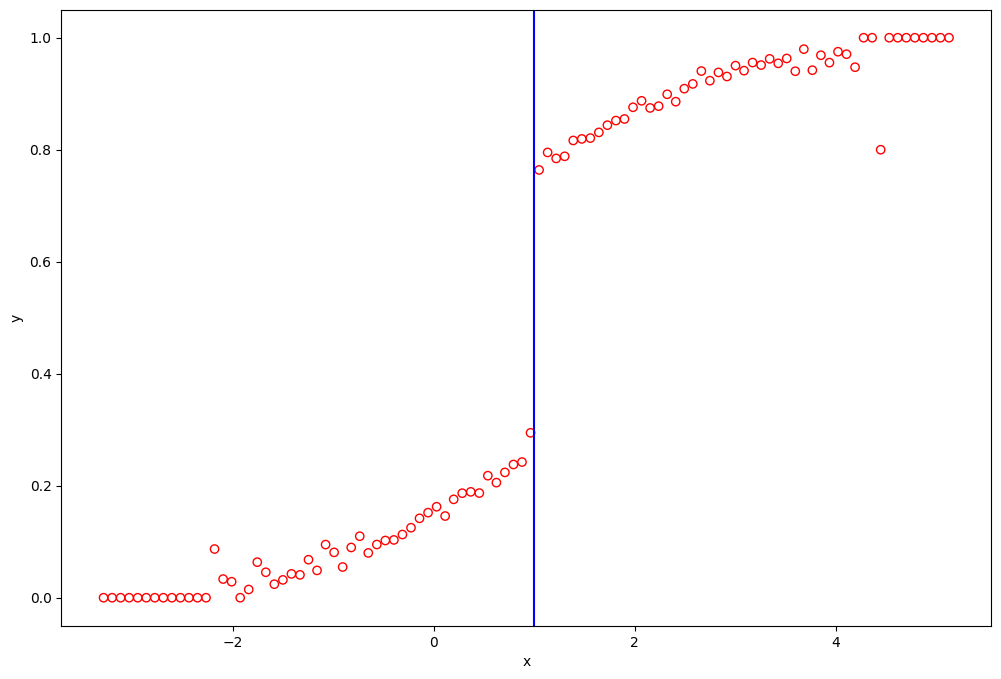

In [23]:
dens = rdd.density_test(data, 'x', 'w', n_bins = 100)

plt.figure(figsize=(12, 8))
plt.scatter(dens.mid_point, dens.w_density, facecolors='none', edgecolors='r')
plt.axvline(x=cutoff, color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.close()

### Calculando o Bandwidth Fuzzy
É preciso passar W como parâmetro porque o cutoff não é condição suficiente no Fuzzy

In [24]:
hopt = rdd.ik_fuzzy_bandwidth(data, "x", "y", "w", cut=1)
hopt

{'hopt_y': np.float64(0.8718886124235146),
 'hopt_w': np.float64(0.7927707859913926)}

### Aplicando Fuzzy RDD

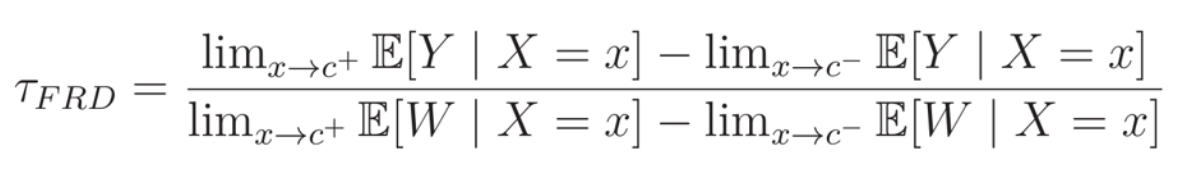

In [25]:
resp = rdd.fuzzy_rdd(data, "x", "y", "w", cut=cutoff, bw_y=None, bw_w=None, kernel=None)
resp

y~x*threshold
w~x*threshold


{'impact': np.float64(0.510287107673146),
 'model_y': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7bef03327770>,
 'model_w': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7bef03472360>}

In [26]:
resp['model_y'].summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.1231,0.003,903.119,0.000,3.116,3.130
x,2.0407,0.003,587.955,0.000,2.034,2.047
threshold,0.2687,0.005,55.117,0.000,0.259,0.278
x:threshold,-0.0038,0.005,-0.779,0.436,-0.013,0.006


In [27]:
resp['model_w'].summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2497,0.003,91.209,0.000,0.244,0.255
x,0.0929,0.003,33.816,0.000,0.088,0.098
threshold,0.5266,0.004,136.461,0.000,0.519,0.534
x:threshold,-0.0080,0.004,-2.063,0.039,-0.016,-0.000


## Exercício
Avalie a contribuição do bandwidth e do kernel neste exemplo de RDD Fuzzy

In [28]:
resp = rdd.fuzzy_rdd(data, "x", "y", "w", cut=cutoff, bw_y=hopt['hopt_y'], bw_w=hopt['hopt_w'], kernel=None)
resp

y~x*threshold
w~x*threshold


{'impact': np.float64(0.4874970152373789),
 'model_y': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7bef032fa0c0>,
 'model_w': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7bef033a8650>}

In [29]:
resp['model_y'].summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.1355,0.004,708.142,0.000,3.127,3.144
x,2.0705,0.009,224.096,0.000,2.052,2.089
threshold,0.2473,0.006,39.572,0.000,0.235,0.260
x:threshold,-0.0175,0.013,-1.336,0.182,-0.043,0.008


In [30]:
resp['model_w'].summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2593,0.005,55.823,0.000,0.250,0.268
x,0.1130,0.011,10.711,0.000,0.092,0.134
threshold,0.5073,0.007,77.403,0.000,0.494,0.520
x:threshold,-0.0095,0.015,-0.634,0.526,-0.039,0.020


In [31]:
resp = rdd.fuzzy_rdd(data, "x", "y", "w", cut=cutoff, bw_y=hopt['hopt_y'], bw_w=hopt['hopt_w'], kernel="triang")
resp

y~x*threshold
w~x*threshold


{'impact': np.float64(0.4912229428456571),
 'model_y': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7bef032f2f00>,
 'model_w': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7bef03429b20>}

In [32]:
resp['model_y'].summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.1366,0.004,830.679,0.000,3.129,3.144
x,2.0744,0.011,187.973,0.000,2.053,2.096
threshold,0.2477,0.005,46.484,0.000,0.237,0.258
x:threshold,-0.0268,0.016,-1.721,0.085,-0.057,0.004


In [33]:
resp['model_w'].summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2615,0.004,62.437,0.000,0.253,0.270
x,0.1217,0.013,9.111,0.000,0.096,0.148
threshold,0.5043,0.006,85.334,0.000,0.493,0.516
x:threshold,-0.0152,0.019,-0.804,0.421,-0.052,0.022


## 7. Integridade do Ponto de Corte (Density Test)

Como auditores, devemos verificar se houve **manipulação**. Se os indivíduos conseguem alterar sua posição na variável $X$ para 'forçar' a entrada no tratamento, haverá um acúmulo artificial de pessoas logo após o ponto de corte.

O `density_test` (Teste de McCrary) verifica se a densidade de $X$ é contínua no cutoff.

In [34]:
cutoff = 1
data = rdd.sim_data(1000000, cut=cutoff, impact =.5, fuzy=True)
data = data.sort_values(by="x")

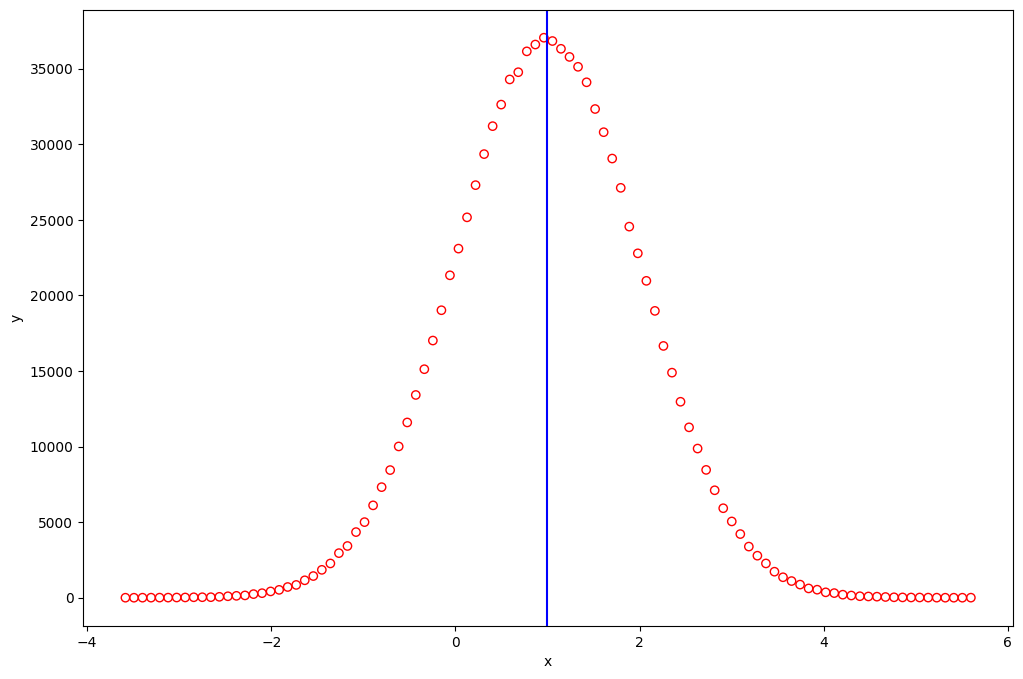

In [35]:
dens = rdd.density_test(data, 'x', 'w', n_bins = 100)

plt.figure(figsize=(12, 8))
plt.scatter(dens.mid_point, dens.x_density, facecolors='none', edgecolors='r')
plt.axvline(x=cutoff, color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.close()

## Estudo de Caso
Avaliação do Efeito da Bebida nas mortes de jovens de 21 anos (Caso dos Estados Unidos)

Paralelo Hipotético no Brasil: Imagine que o Ministério da Saude, atendendo a um pleito dos fabricantes de bebidas, está considerando reduzir a idade mínima para que os jovens possam consumir bebidas alcoólicas. Vc é um auditor que está avaliando se o consumo de bebidas tem influência sobre o número de mortes em jovens.

## Is Alcohol Killing You?
A very relevant public policy question is what should be the minimal drinking age. Most countries, Brazil included, set it to be 18 year, but in the US (most states) it is currently 21. So, is it the case that the US is being overly prudent and that they should lower their minimal drinking age? Or is it the case that other countries should make their legal drinking age higher?

One way to look at this question is from a mortality rate perspective (Carpenter and Dobkin, 2009). From the public policy standpoint, one could argue that we should lower the mortality rate as much as possible. If alcohol consumption increases the mortality rate by a lot, we should avoid lowering the minimum drinking age. This would be consistent with the objective of lowering deaths caused by alcohol consumption.

To estimate the impacts of alcohol on death, we could use the fact that legal drinking age imposes a discontinuity on nature. In the US, those just under 21 years don’t drink (or drink much less) while those just older than 21 do drink. This means that the probability of drinking jumps at 21 years and that is something we can explore with an RDD.


### Dados: rdd_drinkink.csv

In [ ]:
df = pd.read_csv(os.path.join(DATA_PATH, "rdd_drinking.csv"))
df[['agecell', 'all', 'mva', 'suicide' ]].head()

,agecell,all,mva,suicide
0,19.068493,92.825400,35.829327,11.203714
1,19.150684,95.100740,35.639256,12.193368
2,19.232876,92.144295,34.205650,11.715812
3,19.315070,88.427760,32.278957,11.275010
4,19.397260,88.704940,32.650967,10.984314


In [ ]:
df

,agecell,all,allfitted,internal,internalfitted,external,externalfitted,alcohol,alcoholfitted,homicide,homicidefitted,suicide,suicidefitted,mva,mvafitted,drugs,drugsfitted,externalother,externalotherfitted
0,19.068493,92.825400,91.706150,16.617590,16.738130,76.207820,74.968010,0.639138,0.794345,16.316818,16.284573,11.203714,11.592100,35.829327,34.817780,3.872425,3.448835,8.534373,8.388236
1,19.150684,95.100740,91.883720,18.327684,16.920654,76.773056,74.963066,0.677409,0.837575,16.859964,16.270697,12.193368,11.593611,35.639256,34.633890,3.236511,3.470022,8.655786,8.530174
2,19.232876,92.144295,92.049065,18.911053,17.098843,73.233240,74.950226,0.866443,0.877835,15.219254,16.262882,11.715812,11.595129,34.205650,34.446735,3.202071,3.492069,8.513741,8.662681
3,19.315070,88.427760,92.202140,16.101770,17.272680,72.325980,74.929470,0.867308,0.915115,16.742825,16.261148,11.275010,11.596655,32.278957,34.256300,3.280689,3.514980,8.258285,8.785728
4,19.397260,88.704940,92.342920,17.363520,17.442156,71.341415,74.900760,1.019163,0.949407,14.947726,16.265510,10.984314,11.598189,32.650967,34.062588,3.548198,3.538755,8.417533,8.899288
5,19.479452,90.191790,92.471344,17.872105,17.607254,72.319680,74.864090,1.171322,0.980701,15.642815,16.275990,12.166634,11.599731,32.721443,33.865580,3.211689,3.563399,7.972546,9.003332
6,19.561644,96.220310,92.587390,16.414942,17.767965,79.805370,74.819420,0.869916,1.008988,16.263653,16.292604,12.405763,11.601281,36.385197,33.665270,3.857890,3.588913,10.287705,9.097831
7,19.643835,89.615555,92.691020,15.977087,17.924273,73.638466,74.766750,1.097951,1.034261,15.825645,16.315370,10.979514,11.602839,34.187935,33.461647,3.483156,3.615300,8.670031,9.182756
8,19.726027,93.381700,92.782196,17.433271,18.076166,75.948425,74.706024,1.174851,1.056508,16.789000,16.344309,11.900103,11.604405,31.910467,33.254696,4.055130,3.642563,10.763150,9.258081
9,19.808220,90.857956,92.860870,18.285400,18.223630,72.572556,74.637245,0.948413,1.075722,16.616194,16.379436,11.570638,11.605980,30.576832,33.044415,3.566033,3.670704,9.863494,9.323772


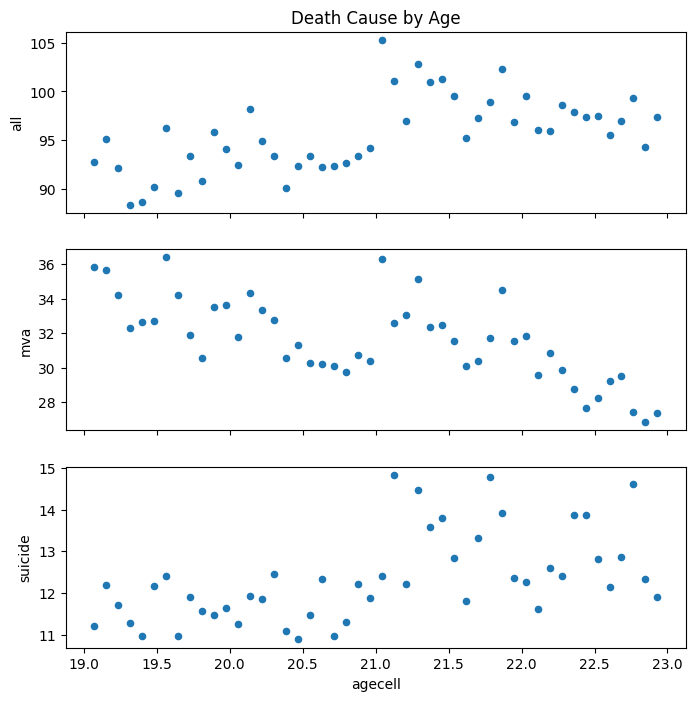

In [ ]:
plt.figure(figsize=(8,8))
ax = plt.subplot(3,1,1)
df.plot.scatter(x="agecell", y="all", ax=ax)
plt.title("Death Cause by Age")

ax = plt.subplot(3,1,2, sharex=ax)
df.plot.scatter(x="agecell", y="mva", ax=ax)

ax = plt.subplot(3,1,3, sharex=ax)
df.plot.scatter(x="agecell", y="suicide", ax=ax);

## Exercício
* Para a variável all:
    * Calcule o BW otimo
    * Aplique RDD Sharp sem BW, com BW, e com Kernel Triangular para a variável all (todas as causas de morte)
    * Avalie os resultados
    * Calcule o impacto percentual em relação ao Intercepto (model.params['threshold']/model.params['Intercept']) para o modelo completo

* Repita o exercício para a variável mva (morte relacionada a veículos)

* Onde o impacto é maior? No geral (all) ou especificamente nas mortes relacionadas com veículos (mva)?

In [ ]:
hopt = rdd.ik_sharp_bandwidth(df, "agecell", "all", cut=21)
hopt

np.float64(1.5949199539202896)

In [ ]:
model = rdd.sharp_rdd(df, "agecell", "all", cut=21, bw=None, kernel=None)
model.summary().tables[1]

all~agecell*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,93.6184,0.932,100.399,0.000,91.739,95.498
agecell,0.8270,0.819,1.010,0.318,-0.823,2.477
threshold,7.6627,1.319,5.811,0.000,5.005,10.320
agecell:threshold,-3.6034,1.158,-3.111,0.003,-5.937,-1.269


In [ ]:
model = rdd.sharp_rdd(df, "agecell", "all", cut=21, bw=hopt, kernel=None)
model.summary().tables[1]

all~agecell*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,93.3504,1.035,90.187,0.000,91.247,95.454
agecell,0.2424,1.148,0.211,0.834,-2.091,2.576
threshold,8.2498,1.464,5.636,0.000,5.275,11.225
agecell:threshold,-3.5487,1.624,-2.185,0.036,-6.849,-0.248


In [ ]:
model = rdd.sharp_rdd(df, "agecell", "all", cut=21, bw=hopt, kernel="triang")
model.summary().tables[1]

all~agecell*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,93.0153,0.878,105.957,0.000,91.231,94.799
agecell,-0.3876,1.349,-0.287,0.776,-3.129,2.354
threshold,9.1282,1.241,7.353,0.000,6.605,11.651
agecell:threshold,-3.9403,1.908,-2.066,0.047,-7.817,-0.064


In [ ]:
model.params['threshold']/model.params['Intercept']

np.float64(0.09813684601768731)

## mva

In [ ]:
model = rdd.sharp_rdd(df, "agecell", "mva", cut=21, bw=None, kernel=None)
model.summary().tables[1]

mva~agecell*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,29.9292,0.531,56.390,0.000,28.860,30.999
agecell,-2.5676,0.466,-5.508,0.000,-3.507,-1.628
threshold,4.5340,0.751,6.041,0.000,3.021,6.047
agecell:threshold,-1.1624,0.659,-1.763,0.085,-2.491,0.166


In [ ]:
model = rdd.sharp_rdd(df, "agecell", "mva", cut=21, bw=hopt, kernel=None)
model.summary().tables[1]

mva~agecell*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,29.8013,0.624,47.753,0.000,28.533,31.070
agecell,-2.8480,0.692,-4.113,0.000,-4.255,-1.441
threshold,4.7688,0.883,5.403,0.000,2.975,6.562
agecell:threshold,-1.0929,0.979,-1.116,0.272,-3.083,0.897


In [ ]:
model = rdd.sharp_rdd(df, "agecell", "mva", cut=21, bw=hopt, kernel="triang")
model.summary().tables[1]

mva~agecell*threshold


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,29.7392,0.513,57.946,0.000,28.696,30.782
agecell,-2.9646,0.789,-3.759,0.001,-4.567,-1.362
threshold,4.7545,0.726,6.551,0.000,3.279,6.229
agecell:threshold,-0.8327,1.115,-0.747,0.460,-3.099,1.434


In [ ]:
model.params['threshold']/model.params['Intercept']

np.float64(0.1598716204361782)